In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.interpolate import CubicSpline
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Preprocessing

In [ ]:
ticker = "AAPL"
df = yf.download(ticker, start = "2010-01-04", end = "2022-12-03")
df.head(10)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.406481,6.421149,6.357686,6.389118,493729600
2010-01-05,6.417555,6.453777,6.383728,6.424141,601904800
2010-01-06,6.315477,6.443002,6.308891,6.417557,552160000
2010-01-07,6.303803,6.346312,6.258002,6.338828,477131200
2010-01-08,6.345711,6.346310,6.258301,6.295420,447610800
2010-01-11,6.289732,6.376245,6.240039,6.370258,462229600
2010-01-12,6.218187,6.279556,6.179272,6.262192,594459600
2010-01-13,6.305897,6.314279,6.109820,6.222677,605892000


In [ ]:
df = df.reindex(pd.date_range(start = df.index.min(), end = df.index.max(), freq = 'D'))
df.head(10)

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
2010-01-04,6.406481,6.421149,6.357686,6.389118,493729600.0
2010-01-05,6.417555,6.453777,6.383728,6.424141,601904800.0
2010-01-06,6.315477,6.443002,6.308891,6.417557,552160000.0
2010-01-07,6.303803,6.346312,6.258002,6.338828,477131200.0
2010-01-08,6.345711,6.346310,6.258301,6.295420,447610800.0
2010-01-09,NaN,NaN,NaN,NaN,NaN
2010-01-10,NaN,NaN,NaN,NaN,NaN
2010-01-11,6.289732,6.376245,6.240039,6.370258,462229600.0
2010-01-12,6.218187,6.279556,6.179272,6.262192,594459600.0


In [ ]:
df2 = pd.DataFrame({})

df2['close'] = df['Close']
df2['high'] = df['High']
df2['low'] = df['Low']
df2['open'] = df['Open']
df2['volume'] = df['Volume']


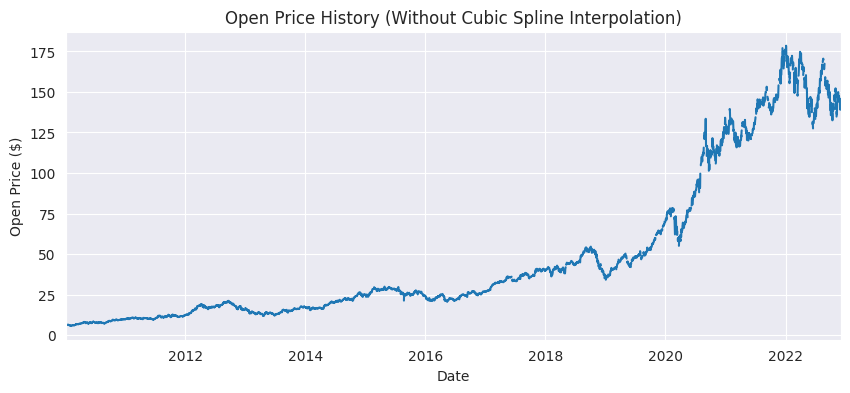

In [ ]:
plt.figure(figsize = (10, 4))
sns.set_style("darkgrid")
df2['open'].plot(kind = "line")
plt.title("Open Price History (Without Cubic Spline Interpolation)")
plt.xlabel("Date")
plt.ylabel("Open Price ($)")
plt.show()

In [ ]:
df2.isna().sum()

,0
close,1463
high,1463
low,1463
open,1463
volume,1463


In [ ]:
close_series_with_gaps = df2['close']

# Cubic Spline Interpolation

In [ ]:
all_idx = np.arange(len(close_series_with_gaps))

In [ ]:
valid_mask = ~close_series_with_gaps.isna()
valid_idx = all_idx[valid_mask]
valid_values = close_series_with_gaps[valid_mask]

In [ ]:
cs = CubicSpline(valid_idx, valid_values)

In [ ]:
interpolated_values = cs(all_idx)

In [ ]:
clean_close_series = pd.Series(interpolated_values, index = close_series_with_gaps.index)

In [ ]:
clean_close_series.head(5)

,0
2010-01-04,6.406481
2010-01-05,6.417555
2010-01-06,6.315477
2010-01-07,6.303803
2010-01-08,6.345711


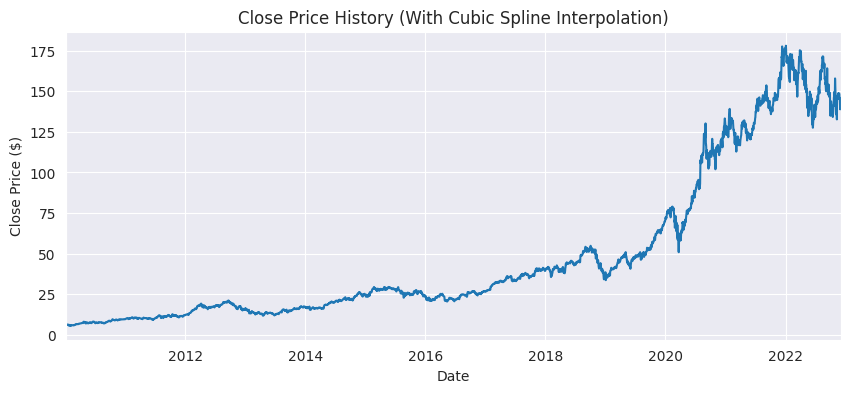

In [ ]:
plt.figure(figsize = (10, 4))
sns.set_style("darkgrid")
clean_close_series.plot(kind = "line")
plt.title("Close Price History (With Cubic Spline Interpolation)")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.show()

# Train-Test-Split

In [ ]:
split_idx = int(len(clean_close_series) * 0.8)
train_series = clean_close_series[:split_idx]
test_series = clean_close_series[split_idx:]

# Stationarity Test

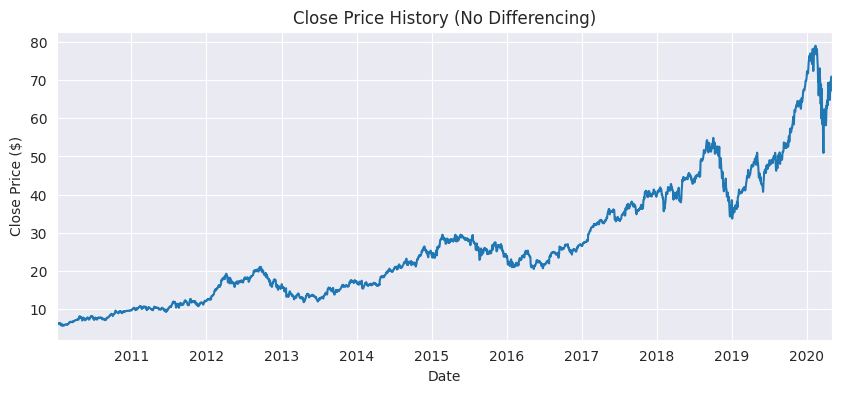

In [ ]:
plt.figure(figsize = (10, 4))
sns.set_style("darkgrid")
train_series.plot(kind = "line")
plt.title("Close Price History (No Differencing)")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.show()

In [ ]:
result = adfuller(train_series)
print("ADF Statistic: %f" % result[0])
print("p-value: %f" % result[1])

ADF Statistic: 0.179886
p-value: 0.971111


In [ ]:
close_series_diff = train_series.diff().dropna()

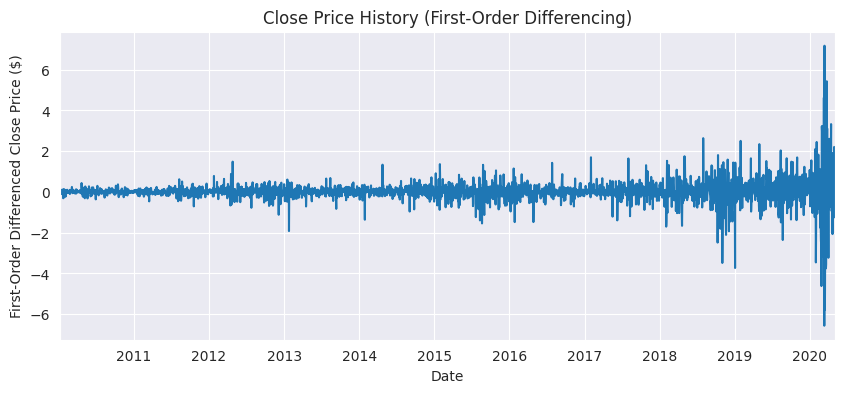

In [ ]:
plt.figure(figsize = (10, 4))
sns.set_style("darkgrid")
close_series_diff.plot(kind = "line")
plt.title("Close Price History (First-Order Differencing)")
plt.xlabel("Date")
plt.ylabel("First-Order Differenced Close Price ($)")
plt.show()

In [ ]:
result1 = adfuller(close_series_diff)
print("ADF Statistic: %f" % result1[0])
print("p-value: %f" % result1[1])

ADF Statistic: -9.645918
p-value: 0.000000


# Model Training - ARIMA

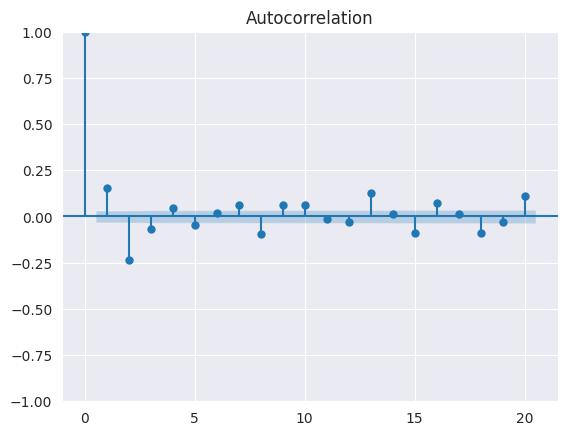

In [ ]:
plot_acf(close_series_diff, lags = 20)
plt.show()

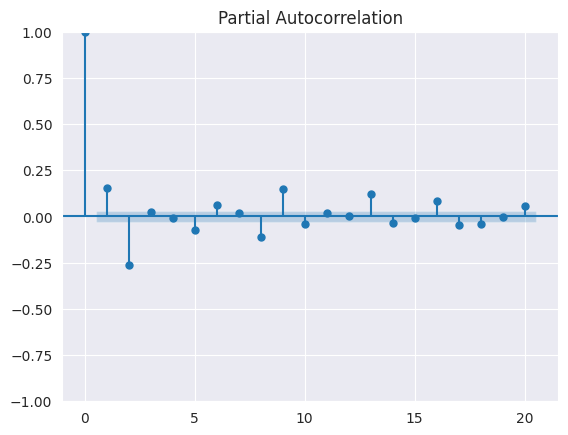

In [ ]:
plot_pacf(close_series_diff, lags = 20)
plt.show()

In [ ]:
model = ARIMA(train_series, order = (2, 1, 3))
model_fitted = model.fit()

print(model_fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3772
Model:                 ARIMA(2, 1, 3)   Log Likelihood               -2602.408
Date:                Sun, 07 Jun 2026   AIC                           5216.815
Time:                        02:38:13   BIC                           5254.226
Sample:                    01-04-2010   HQIC                          5230.116
                         - 05-02-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5753      0.018    -32.292      0.000      -0.610      -0.540
ar.L2         -0.4284      0.013    -34.059      0.000      -0.453      -0.404
ma.L1          0.7822      0.020     39.560      0.0

# Model Evaluation

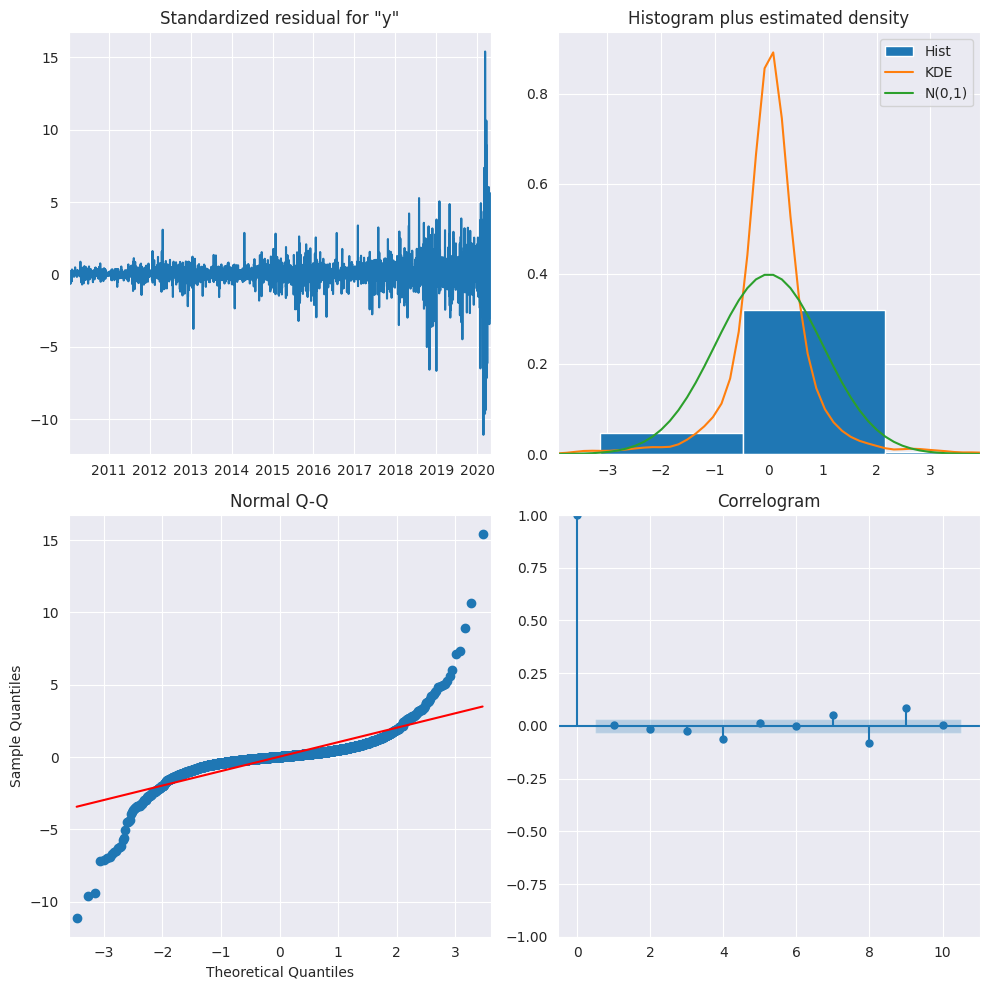

In [ ]:
model_fitted.plot_diagnostics(figsize = (10, 10))
plt.tight_layout()
plt.show()

In [ ]:
lb_results = acorr_ljungbox(model_fitted.resid,
                            lags = list(range(1, 21)),
                            return_df = True)
print(lb_results)

       lb_stat     lb_pvalue
1     0.035572  8.504014e-01
2     0.777641  6.778559e-01
3     2.944787  4.002165e-01
4    16.062979  2.935809e-03
5    16.624949  5.268857e-03
6    16.655130  1.063786e-02
7    26.063652  4.906470e-04
8    48.473386  8.020082e-08
9    72.958769  3.992279e-12
10   72.964625  1.182894e-11
11   80.066422  1.432724e-12
12   85.981224  2.946989e-13
13  124.184446  2.990459e-20
14  126.743223  2.982155e-20
15  146.797831  1.041756e-23
16  163.978643  1.332273e-26
17  165.325846  2.362286e-26
18  173.386284  1.947630e-27
19  177.746615  8.587365e-28
20  217.065105  4.596184e-35


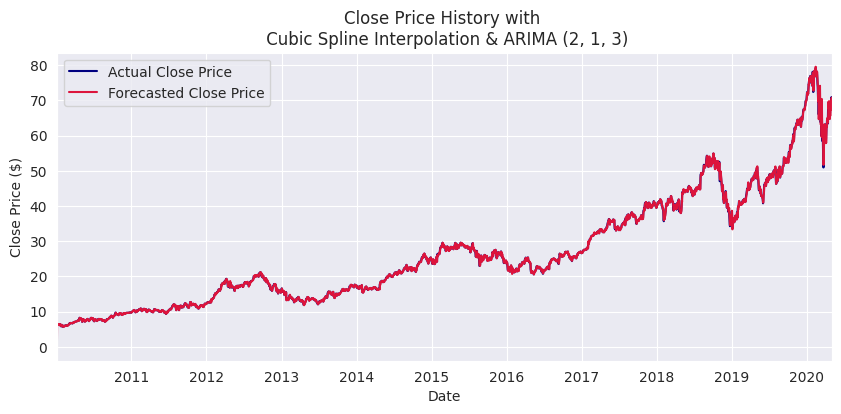

In [ ]:
plt.figure(figsize = (10, 4))
forecast_train = model_fitted.predict(train_series.index[0], train_series.index[-1])
train_series.plot(kind = "line", color = "navy", label = "Actual Close Price")
forecast_train.plot(kind = "line", color = "crimson", label = "Forecasted Close Price")
plt.title("Close Price History with \n Cubic Spline Interpolation & ARIMA (2, 1, 3)")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.legend()
plt.show()

# Rolling Forecast

In [ ]:
history = [x for x in train_series]
predictions = list()

model_f = ARIMA(history, order = (2, 1, 3))
model_fitted_f = model_f.fit()

for i in range(len(test_series)):
  obs = test_series[i]
  model_fitted_f = model_fitted_f.append([obs], refit = False)
  output = model_fitted_f.forecast()
  yhat = output[0]
  predictions.append(yhat)
  history.append(obs)

  print("Progress: {}/{} | Predicted: {:.2f}, Actual: {:.2f}".format(i,len(test_series), yhat, obs))


Progress: 0/944 | Predicted: 69.87, Actual: 69.73
Progress: 1/944 | Predicted: 70.66, Actual: 70.77
Progress: 2/944 | Predicted: 71.99, Actual: 71.83
Progress: 3/944 | Predicted: 72.43, Actual: 72.57
Progress: 4/944 | Predicted: 73.33, Actual: 73.32
Progress: 5/944 | Predicted: 75.34, Actual: 75.07
Progress: 6/944 | Predicted: 76.04, Actual: 76.26
Progress: 7/944 | Predicted: 76.43, Actual: 76.59
Progress: 8/944 | Predicted: 76.24, Actual: 76.25
Progress: 9/944 | Predicted: 75.22, Actual: 75.38
Progress: 10/944 | Predicted: 74.50, Actual: 74.47
Progress: 11/944 | Predicted: 75.23, Actual: 74.93
Progress: 12/944 | Predicted: 74.19, Actual: 74.48
Progress: 13/944 | Predicted: 75.16, Actual: 74.95
Progress: 14/944 | Predicted: 76.16, Actual: 75.97
Progress: 15/944 | Predicted: 75.89, Actual: 76.24
Progress: 16/944 | Predicted: 75.79, Actual: 75.80
Progress: 17/944 | Predicted: 77.73, Actual: 77.27
Progress: 18/944 | Predicted: 76.10, Actual: 76.70
Progress: 19/944 | Predicted: 77.48, Actu

In [ ]:
print("MAE: {:.4f}".format(mean_absolute_error(test_series, predictions)))
print("RMSE: {:.4f}".format(np.sqrt(mean_squared_error(test_series, predictions))))
print("R2: {:.4f}".format(r2_score(test_series, predictions)))

MAE: 0.5187
RMSE: 0.7318
R2: 0.9991


In [ ]:
predictions_df = pd.Series(predictions, index = test_series.index)

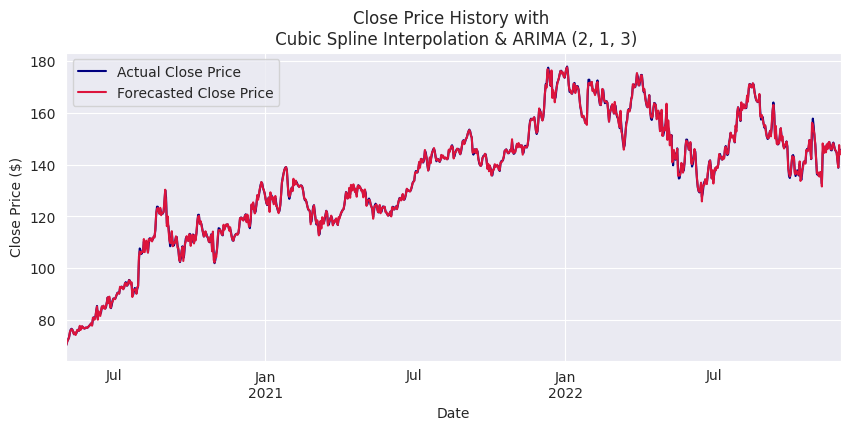

In [ ]:
plt.figure(figsize = (10, 4))
test_series.plot(kind = "line", color = "navy", label = "Actual Close Price")
predictions_df.plot(kind = "line", color = "crimson", label = "Forecasted Close Price")
plt.title("Close Price History with \n Cubic Spline Interpolation & ARIMA (2, 1, 3)")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.legend()
plt.show()